In [ ]:
# Determine coin outcomes.
# Connect to coin_table
# create a new column outcomes
# if a coin is rugpulled then outcome is rugpull
# if a coin's price is >95% loss in value then outcome is dead

In [1]:
import db_utils
import sqlite3
import pandas as pd

# Connect to 
conn = sqlite3.connect('main.db')
df = pd.read_sql_query("SELECT * FROM coin_table", conn)
df.head()

,id,event_signature,exchange,creation_timestamp,coin_address,pair_address,coin_name,coin_symbol,creator,initial_liquidity,initial_price,ath_time_delta,ath_price_gain,rugpull_flag,rugpull_timestamp,rugpull_time_delta
0,1,4UY8oNkwJYnN993EEQdHwwFLLrB3w4y6s1GNfB3cDpcFwX...,Raydium AMM v4,1745303998,D8qMn1hGsv2JXmbmF4eT1X1B7RMqcn4Xq9p37o352ZrQ,F64aTfzVqa1DzbqYEdk8DnwhKKcfJFFsxWitaq4h5zqL,TURBO Official,$TURBO,3UQrEHzpVck32DV16jDqR2pUDZaeTCisKovADGAxL4dQ,1734.550164,2.000685e-07,362.0,243.363218,1,1745304669,671.0
1,2,2oJjmssn2LAB7yZCRrKpzBzzoeoFKNXS8G2e3xakon34or...,Pump Fun,1745304054,9fea2FVFHFrF4ETtFRiHNVFDW7taaQb1TqfdMrWDhGzV,B1MyLLNi8kVBF4FqDSF7JmiyXAAB6F4TLX5mvZgEA1RM,Poggers,POG,FZFnbDNBKkMNnqwkeP4eGVJy7rA4qncUQQ8UePbgGTUr,9546.328175,1.307660e-04,366.0,1452.629150,1,1745304542,488.0
2,3,5AHUVMgsAgZBCQuCHfL1BrTistpkNu1pXE5ckF7RmUCdWS...,Pump Fun,1745304062,ATWdzJZj6NDHSPZ8TE6cWmhqxViMr2hc7do6u7kSYwUd,4BMaMGUdzKWHwmEj4S3f5nkSDrkP8gdMeZzobgJw7uYC,Make Tariff High Again,MTHA,5dsyS11LnM5kii7v5W7q4YMonWYc6Q6cF9mGhqJPuoMK,56583.029113,4.995577e-06,1138.0,31.311362,1,1745305266,1204.0
3,4,3n7ZmJ26RybkbvyhauqE4QaTBp45dPFwhkzUzX6q3eYxb3...,Pump Fun,1745304078,6yi18Db9RMtx7kFJ9S8fVUJeK5RiyqnFQEZEWfuiCFqZ,6vYqLxusRxvKojx8qV973UiLtkMi5PeoUPgymWiSNL5k,Infinite USDT Glitch,IUG,4FZgwVEf1d4dhSnqb3eeLeNE7PucC9tFiAxggzQEKoFV,33740.081016,8.315980e-05,162.0,2751.507279,1,1745304445,367.0
4,5,3QNTLf3Z2kt99yCqCQsEadG1ENwJqmipNDGCoaojQrZfE3...,Pump Fun,1745304090,EJB6qTdLeRSc5ETGcPk685HCfXnRJ9ckq6QdLwZSpump,7Jdra7AQsCBcAqh9qvRcpZv4efShR3StFbjcSK3CiU1S,Poseidon Pepe,POPE,TSLvdd1pWpHVjahSpsvCXUbgwsL3JAcvokwaKt1eokM,30713.094782,8.763433e-05,NaN,NaN,0,None,NaN


In [3]:
# set all to undetermined
df['outcomes'] = 'undetermined'

# if rugpull_flag is 1 then outcome is rugpull
df.loc[df['rugpull_flag'] == 1, 'outcomes'] = 'rugpull'

df.head()

,id,event_signature,exchange,creation_timestamp,coin_address,pair_address,coin_name,coin_symbol,creator,initial_liquidity,initial_price,ath_time_delta,ath_price_gain,rugpull_flag,rugpull_timestamp,rugpull_time_delta,outcomes
0,1,4UY8oNkwJYnN993EEQdHwwFLLrB3w4y6s1GNfB3cDpcFwX...,Raydium AMM v4,1745303998,D8qMn1hGsv2JXmbmF4eT1X1B7RMqcn4Xq9p37o352ZrQ,F64aTfzVqa1DzbqYEdk8DnwhKKcfJFFsxWitaq4h5zqL,TURBO Official,$TURBO,3UQrEHzpVck32DV16jDqR2pUDZaeTCisKovADGAxL4dQ,1734.550164,2.000685e-07,362.0,243.363218,1,1745304669,671.0,rugpull
1,2,2oJjmssn2LAB7yZCRrKpzBzzoeoFKNXS8G2e3xakon34or...,Pump Fun,1745304054,9fea2FVFHFrF4ETtFRiHNVFDW7taaQb1TqfdMrWDhGzV,B1MyLLNi8kVBF4FqDSF7JmiyXAAB6F4TLX5mvZgEA1RM,Poggers,POG,FZFnbDNBKkMNnqwkeP4eGVJy7rA4qncUQQ8UePbgGTUr,9546.328175,1.307660e-04,366.0,1452.629150,1,1745304542,488.0,rugpull
2,3,5AHUVMgsAgZBCQuCHfL1BrTistpkNu1pXE5ckF7RmUCdWS...,Pump Fun,1745304062,ATWdzJZj6NDHSPZ8TE6cWmhqxViMr2hc7do6u7kSYwUd,4BMaMGUdzKWHwmEj4S3f5nkSDrkP8gdMeZzobgJw7uYC,Make Tariff High Again,MTHA,5dsyS11LnM5kii7v5W7q4YMonWYc6Q6cF9mGhqJPuoMK,56583.029113,4.995577e-06,1138.0,31.311362,1,1745305266,1204.0,rugpull
3,4,3n7ZmJ26RybkbvyhauqE4QaTBp45dPFwhkzUzX6q3eYxb3...,Pump Fun,1745304078,6yi18Db9RMtx7kFJ9S8fVUJeK5RiyqnFQEZEWfuiCFqZ,6vYqLxusRxvKojx8qV973UiLtkMi5PeoUPgymWiSNL5k,Infinite USDT Glitch,IUG,4FZgwVEf1d4dhSnqb3eeLeNE7PucC9tFiAxggzQEKoFV,33740.081016,8.315980e-05,162.0,2751.507279,1,1745304445,367.0,rugpull
4,5,3QNTLf3Z2kt99yCqCQsEadG1ENwJqmipNDGCoaojQrZfE3...,Pump Fun,1745304090,EJB6qTdLeRSc5ETGcPk685HCfXnRJ9ckq6QdLwZSpump,7Jdra7AQsCBcAqh9qvRcpZv4efShR3StFbjcSK3CiU1S,Poseidon Pepe,POPE,TSLvdd1pWpHVjahSpsvCXUbgwsL3JAcvokwaKt1eokM,30713.094782,8.763433e-05,NaN,NaN,0,None,NaN,undetermined


<Axes: xlabel='outcomes'>

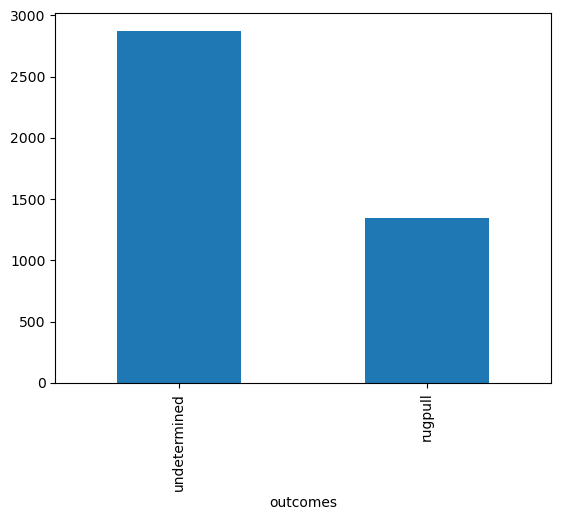

In [5]:
# bar plot of outcomes
df['outcomes'].value_counts().plot(kind='bar')

In [8]:
import requests
import time
from tqdm import tqdm

def get_coin_data(coin_address: str):
    url = f"https://api.rugcheck.xyz/v1/tokens/{coin_address}/report"
    resp = requests.get(url)
    resp.raise_for_status()
    time.sleep(2)
    data_dict = resp.json()
    return data_dict

undetermined_df = df[df['outcomes'] == 'undetermined']

for index, row in tqdm(undetermined_df.iterrows(), total=len(undetermined_df)):
    coin_address = row['coin_address']
    initial_price = row['initial_price']
    initial_liquidity = row['initial_liquidity']
    price = None
    liquidity = None

    try:
        data = get_coin_data(coin_address)
        price = data["price"]
        liquidity = data["totalMarketLiquidity"]
    except Exception as e:
        print(f"Error fetching coin data for {coin_address}: {e}")
        continue

    if price is None or liquidity is None:
        continue

    if price < initial_price * 0.05:
        df.loc[index, 'outcomes'] = 'dead'
    elif liquidity < initial_liquidity * 0.05:
        df.loc[index, 'outcomes'] = 'dead'
    else:
        df.loc[index, 'outcomes'] = 'alive'



100%|██████████| 2874/2874 [2:35:30<00:00,  3.25s/it]  


<Axes: xlabel='outcomes'>

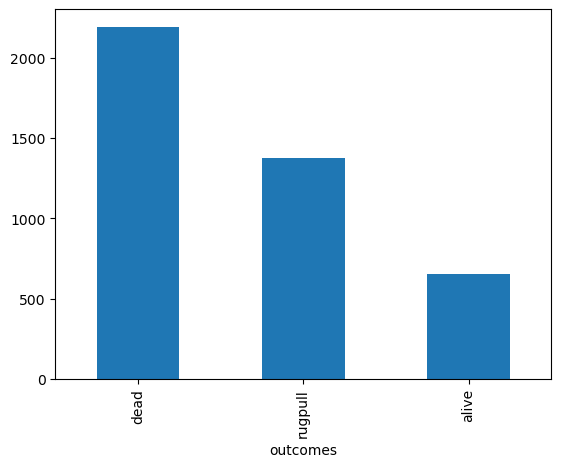

In [43]:
df['outcomes'].value_counts().plot(kind='bar')

In [37]:
# save df to csv
df.to_csv("data/post/main.csv")

In [42]:
df.to_csv("data/post/main_2.csv")

In [18]:
df.head(20)

,id,event_signature,exchange,creation_timestamp,coin_address,pair_address,coin_name,coin_symbol,creator,initial_liquidity,initial_price,ath_time_delta,ath_price_gain,rugpull_flag,rugpull_timestamp,rugpull_time_delta,outcomes
0,1,4UY8oNkwJYnN993EEQdHwwFLLrB3w4y6s1GNfB3cDpcFwX...,Raydium AMM v4,1745303998,D8qMn1hGsv2JXmbmF4eT1X1B7RMqcn4Xq9p37o352ZrQ,F64aTfzVqa1DzbqYEdk8DnwhKKcfJFFsxWitaq4h5zqL,TURBO Official,$TURBO,3UQrEHzpVck32DV16jDqR2pUDZaeTCisKovADGAxL4dQ,1734.550164,2.000685e-07,362.0,243.363218,1,1745304669,671.0,rugpull
1,2,2oJjmssn2LAB7yZCRrKpzBzzoeoFKNXS8G2e3xakon34or...,Pump Fun,1745304054,9fea2FVFHFrF4ETtFRiHNVFDW7taaQb1TqfdMrWDhGzV,B1MyLLNi8kVBF4FqDSF7JmiyXAAB6F4TLX5mvZgEA1RM,Poggers,POG,FZFnbDNBKkMNnqwkeP4eGVJy7rA4qncUQQ8UePbgGTUr,9546.328175,1.307660e-04,366.0,1452.629150,1,1745304542,488.0,rugpull
2,3,5AHUVMgsAgZBCQuCHfL1BrTistpkNu1pXE5ckF7RmUCdWS...,Pump Fun,1745304062,ATWdzJZj6NDHSPZ8TE6cWmhqxViMr2hc7do6u7kSYwUd,4BMaMGUdzKWHwmEj4S3f5nkSDrkP8gdMeZzobgJw7uYC,Make Tariff High Again,MTHA,5dsyS11LnM5kii7v5W7q4YMonWYc6Q6cF9mGhqJPuoMK,56583.029113,4.995577e-06,1138.0,31.311362,1,1745305266,1204.0,rugpull
3,4,3n7ZmJ26RybkbvyhauqE4QaTBp45dPFwhkzUzX6q3eYxb3...,Pump Fun,1745304078,6yi18Db9RMtx7kFJ9S8fVUJeK5RiyqnFQEZEWfuiCFqZ,6vYqLxusRxvKojx8qV973UiLtkMi5PeoUPgymWiSNL5k,Infinite USDT Glitch,IUG,4FZgwVEf1d4dhSnqb3eeLeNE7PucC9tFiAxggzQEKoFV,33740.081016,8.315980e-05,162.0,2751.507279,1,1745304445,367.0,rugpull
4,5,3QNTLf3Z2kt99yCqCQsEadG1ENwJqmipNDGCoaojQrZfE3...,Pump Fun,1745304090,EJB6qTdLeRSc5ETGcPk685HCfXnRJ9ckq6QdLwZSpump,7Jdra7AQsCBcAqh9qvRcpZv4efShR3StFbjcSK3CiU1S,Poseidon Pepe,POPE,TSLvdd1pWpHVjahSpsvCXUbgwsL3JAcvokwaKt1eokM,30713.094782,8.763433e-05,NaN,NaN,0,None,NaN,dead
5,6,42urDw3H4T1fi7MYvu64gt3gEfjrsP7MHXNsrXFQEbJsbv...,Pump Fun,1745304196,79jKG2XvTzDMdFZzbaJGvzZjLkV9zp9Sk34zrHdpump,CtVAaigzmMaPr62We47nUj8B7SMHJ2oAE7VJ87m95A2b,Kanye West,YE,5Z25HrnoycdXQAvvGtCzPosHgBMWFBPcdvKx4oWHDUqs,24571.201438,6.166078e-05,644.0,21.721204,1,1745304881,685.0,rugpull
6,7,3VmdDBT2Kdg1p7pZ7gjceAUuiSqW8tfKdqnU7WoNC5rGN2...,Pump Fun,1745304273,7ajXnZAQVHcVrdNqhRZTM2zK2cfvASycEebpv1yjXen7,491Ayagkkqvu58GkxjntoDPjRsS3xip8bPeF1hQSKWj8,Riley Reid,REID,F9kWQUXjEgzUFPKZ7hjTkgv49nC7weW33tkCTLSZM7Kp,195162.615869,4.739332e-04,1887.0,7.008416,1,1745306244,1971.0,rugpull
7,8,4KETnfXYadYESd31FXuHfD8MLvvhPB9du4xEoNvmPXL852...,Raydium AMM v4,1745304487,9sdFWg4ozxUvyxn9nx1by1Xs2HqevPsVCLQx4TNo3VLe,5mReBZQ8QgnuZth2LqPAzEgCGvL9dBNAVy2s5ZHqZiuA,Poseidon,POSEIDON,9hg6m752RmnrPvJFoCrY3RaV8eFdpnjRSft3NohHbF22,38756.546806,5.908748e-02,NaN,NaN,0,None,NaN,dead
8,9,2YMvvDBF9XmXjbmNLqcCWWX3aGNcrbW7ujsSMoKqfe7Xyb...,Raydium CLMM,1745304568,2eT7Qd71KWiH2TUZVr7wQkbzTRCXAi75c4YstuJ6hb41,F5eCwYdd4fB8FjyTdU3DLrHGQN2s8J3nDf8kawguPbvS,The Clever Galapagos Hunter,Sol,6wro8H4PdojEG11uAMjSa2yvte93U4rQYqCxSZPxipFb,14970.629613,9.409439e-05,NaN,NaN,0,None,NaN,dead
9,10,2SouQ2WyzQK38ygWjkFSf9bXCqhXXbPLGeyk4SmnpadWBK...,Pump Fun,1745304613,14JcLsN3AsT1bqgf5Yqw4BwF6MvpPxwL6UEbevjspump,5KDJoJ1iXeTeDxJWokohgEXiuwpUhZHJZRuzz2FBTJfp,Poseidon,POSEIDON,GJBenFHrZH6YFUqzryUhUnC5LhgzdTtKUUdWj7B6utFe,67607.426182,1.675316e-04,707.0,12.378766,1,1745305400,787.0,rugpull


In [26]:
import yaml

with open("config.yaml", "r") as f:
    config = yaml.safe_load(f) or {}
threshold = config["monitor"]["threshold"]
# RPC endpoint
rpc_http = config["solana"]["rpc_http"]
# program IDs to scan for withdraw instructions
amm_program_ids = {p["id"] for p in config.get("solana", {}).get("programs", {}).values()}

In [41]:
from solana.rpc.api import Client
from solders.pubkey import Pubkey
import json
import os
from decode import decode_raydium, decode_pumpfun

def creator_mechanism(coin_address: str, pair_address: str, creator: str, exchange: str) -> bool:
    """
    Mechanism 1: detect if the creator has withdrawn liquidity from the pair.
    Fetch recent transactions for the pair_address, look for any 'withdraw' instruction.
    Returns True if a withdraw instruction is found, False otherwise.
    """

    # initialize RPC client
    client = Client(rpc_http)
    try:
        # fetch signatures involving the pair (liquidity pool)
        resp = client.get_signatures_for_address(Pubkey.from_string(creator), limit=100)
        time.sleep(2)
        sigs = resp.value
    except Exception:
        return False, None

    # scan each transaction for a withdraw instruction
    for info in sigs:
        sig = info.signature
        if not sig:
            continue
        try:
            # fetch parsed transaction details
            tx = client.get_transaction(sig, encoding='jsonParsed', commitment='confirmed', max_supported_transaction_version=0)
            time.sleep(0.25)
            # Save the transaction to a file
            with open('transaction_temp.json', 'w') as f:
                f.write(tx.to_json())
            with open('transaction_temp.json', 'r') as f:
                tx_dict = json.load(f)
        except Exception as e:
            print(f"Error fetching transaction {sig}: {e}")
            # check if the file exists
            if os.path.exists('transaction_temp.json'):
                os.remove('transaction_temp.json')
            continue
        # delete the transaction file
        os.remove('transaction_temp.json')

        if tx_dict is None:
            continue
        if tx_dict["result"] is None:
            continue
       
        # parse the transaction
        instructions = tx_dict["result"]["transaction"]["message"]["instructions"]
        signature = tx_dict["result"]["transaction"]["signatures"][0]
        if signature == "5NgJ6ToLpyMKXrVZtMMiUngHoa7SkUbMbLA2Cpn1PQ6Xr32huU8FEveNfdxKbnKKYBuDfX9aTap8oKLnjLs1xtB7":
            print("Here")
        log_messages = tx_dict["result"]["meta"]["logMessages"]
        log_string = " ".join(log_messages)
        blocktime = tx_dict["result"]["blockTime"]
        # Check #1:
        try:
            if "raydium" in exchange.lower():
                for instruction in instructions:
                    if 'data' in instruction:
                        data = instruction['data']
                        decoded = decode_raydium(data)
                        if decoded['name'] == 'Withdraw':
                            return True, blocktime
            if "pump" in exchange.lower():
                for instruction in instructions:
                    if 'data' in instruction:
                        data = instruction['data']
                        decoded = decode_pumpfun(data)
                        if decoded['name'] == 'withdraw':
                            return True, blocktime
            # Check #2
            if "Withdraw" in log_string:
                for instruction in instructions:
                    if "accounts" in instruction:
                        accounts = instruction["accounts"]
                        if coin_address in accounts and pair_address in accounts:
                            return True, blocktime
        except Exception as e:
            print(f"Error checking withdrawals for {coin_address}: {e}")
            return False, None
    return False, None

alive_df = df[df['outcomes'] == 'alive']
print(alive_df.shape)

for index, row in tqdm(alive_df.iterrows(), total=len(alive_df)):
    coin_address = row['coin_address']
    pair_address = row['pair_address']
    creator = row['creator']
    exchange = row['exchange']
    created_ts = int(row['creation_timestamp'])
    # run creator_mechanism
    rugpull_flag, rugpull_time = creator_mechanism(coin_address, pair_address, creator, exchange)
    if rugpull_flag and rugpull_time:
        # Update the rugpull flag and time, and time delta
        rugpull_time_delta = rugpull_time - created_ts
        df.loc[index, 'outcomes'] = 'rugpull'
        df.loc[index, 'rugpull_time_delta'] = rugpull_time_delta
        df.loc[index, 'rugpull_flag'] = 1
        df.loc[index, 'rugpull_time'] = rugpull_time
        continue

    initial_price = row['initial_price']
    initial_liquidity = row['initial_liquidity']
    price = None
    liquidity = None

    try:
        data = get_coin_data(coin_address)
        price = data["price"]
        liquidity = data["totalMarketLiquidity"]
    except Exception as e:
        print(f"Error fetching coin data for {coin_address}: {e}")
        continue

    if price is None or liquidity is None:
        continue

    if price < initial_price * 0.05:
        df.loc[index, 'outcomes'] = 'dead'
    elif liquidity < initial_liquidity * 0.05:
        df.loc[index, 'outcomes'] = 'dead'
    else:
        df.loc[index, 'outcomes'] = 'alive'

(727, 18)


 28%|██▊       | 205/727 [2:08:29<7:16:32, 50.18s/it]

Error fetching transaction 2NUoy197orRqbzdUBduArChPAZqQoYpHDPgjTP91fGV3kzLa1oUXPeZ1eGTENg5CxMKn4Fvb9H7hNeDhYnrGt84R: 


 28%|██▊       | 206/727 [2:09:39<8:08:08, 56.21s/it]

Error fetching transaction 39EkHYyDwoVVWkowdHgZkGrRpVawtTn7mnKkFv8vWu35s6E4SxNqo8JbkqgTwB2o3NfwGnmJa85RF6XyNnbrtiFB: 


...

Error fetching transaction 2qrkzePyZWfMVkUJcCmVv4F1S99x1o6AXiK5ofEVSaMx7F5MBSm5iySw6YYRpjB7PSRmQT6y3uhw5htYhGVnnJLw: 


 47%|████▋     | 340/727 [3:34:35<5:53:29, 54.80s/it] 

Error fetching transaction 4vkDgk7fqbkG62No71FaT2HkteW6TAUq874gAZHqr7DqPq3gySqnh14zZg2X1mr3B6aXG8ruDA84DuLAp2HmJX8N: 
Error fetching transaction 2RxFqbJJ3NcBQV2XpHEaqcB9KfcSihmwtXmdxfznrJeGvR5fZCKQZ7pEhKf14aM2RW9rvkHdndiuykSPzLMgKYS1: 
Error fetching transaction 23MBRdJNRG8fx7yYKWQsXnmo2ZD5MaRL1i7Kiqduz4a5P9jQQinTf4NNWAsizo6pT8ya2bgedgGDubXxMPYTQsDw: 
Error fetching transaction 2mhpqBcY7ZhfLQAsXw451zENJ22cMHFQyiqZDRybsLJqF2i8fMpF4sAyHox3Hia34jLwVy5ktsjkL5dLeRgjfgYN: 


 72%|███████▏  | 522/727 [5:38:36<2:12:58, 38.92s/it]


KeyboardInterrupt: 

In [39]:
# print unique values
alive_df['outcomes'].unique()

array(['alive'], dtype=object)